<a href="https://colab.research.google.com/github/eltongaspar/Dio/blob/Advpl/Aula_06_Aluno_Fundamentos_Visao_Computacional_OpenCV_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 6 – Fundamentos de Visão Computacional com OpenCV

## Versão do Aluno

### Capacidades
- Aplicar visão computacional.
- Demonstrar atenção a detalhes na interpretação de imagens digitais.

### Conhecimentos
- Conceito de visão computacional.
- Pixels e canais RGB.
- Uso básico do OpenCV.
- Conversão RGB/BGR.
- Tons de cinza.
- Redimensionamento.
- Histogramas.
- Filtros.
- Detecção de bordas.
- Limiarização.

# 1. Contextualização

Nesta aula, vamos utilizar o dataset CIFAR-10 e a biblioteca OpenCV.

Complete durante a aula:

A visão computacional permite que o computador interprete imagens e vídeos digitais.

Na indústria, ela pode ser usada para inspeção de qualidade, detecção de defeitos e automação de processos produtivos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

from tensorflow.keras.datasets import cifar10

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)

TensorFlow: 2.20.0
OpenCV: 4.13.0


In [2]:
imagens = cifar10.load_data()
imagens

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


((array([[[[ 59,  62,  63],
           [ 43,  46,  45],
           [ 50,  48,  43],
           ...,
           [158, 132, 108],
           [152, 125, 102],
           [148, 124, 103]],
  
          [[ 16,  20,  20],
           [  0,   0,   0],
           [ 18,   8,   0],
           ...,
           [123,  88,  55],
           [119,  83,  50],
           [122,  87,  57]],
  
          [[ 25,  24,  21],
           [ 16,   7,   0],
           [ 49,  27,   8],
           ...,
           [118,  84,  50],
           [120,  84,  50],
           [109,  73,  42]],
  
          ...,
  
          [[208, 170,  96],
           [201, 153,  34],
           [198, 161,  26],
           ...,
           [160, 133,  70],
           [ 56,  31,   7],
           [ 53,  34,  20]],
  
          [[180, 139,  96],
           [173, 123,  42],
           [186, 144,  30],
           ...,
           [184, 148,  94],
           [ 97,  62,  34],
           [ 83,  53,  34]],
  
          [[177, 144, 116],
           [16

# 2. Carregamento do dataset CIFAR-10

Complete:

O CIFAR-10 possui imagens coloridas de 32 x 32 pixels.

Cada imagem possui 3 canais de cor.

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

classes = [
    "avião", "automóvel", "pássaro", "gato", "cervo",
    "cachorro", "sapo", "cavalo", "navio", "caminhão"
]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (50000, 32, 32, 3)
y_train: (50000, 1)
x_test: (10000, 32, 32, 3)
y_test: (10000, 1)


In [15]:
import random

indice = random.randint(0, len(x_train) - 1)
print(f"Índice aleatório gerado: {indice}")

Índice aleatório gerado: 32737


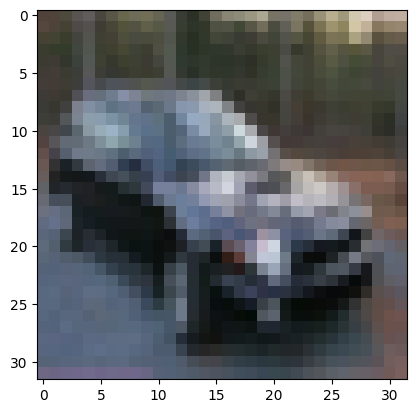

In [16]:
img= x_train[indice]
plt.imshow(img)

# 3. Análise inicial de uma imagem

Execute a célula e responda:

- Classe da imagem: Carro
- Formato da imagem: 32 x 32 pixels
- Valor mínimo de pixel: 0
- Valor máximo de pixel: 255

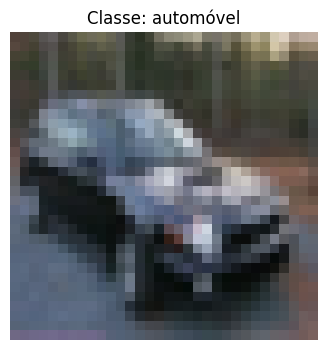

Formato: (32, 32, 3)
Tipo de dado: uint8
Valor mínimo: 3
Valor máximo: 225
Exemplo de pixel [0,0]: [80 65 57]


In [17]:
indice = indice
imagem_rgb = x_train[indice]
classe = int(y_train[indice][0])
classe
plt.figure(figsize=(4,4))
plt.imshow(imagem_rgb)
plt.title(f"Classe: {classes[classe]}")
plt.axis("off")
plt.show()

print("Formato:", imagem_rgb.shape)
print("Tipo de dado:", imagem_rgb.dtype)
print("Valor mínimo:", imagem_rgb.min())
print("Valor máximo:", imagem_rgb.max())
print("Exemplo de pixel [0,0]:", imagem_rgb[0,0])

# 4. RGB e BGR no OpenCV

Complete:

O Matplotlib trabalha normalmente com imagens em padrão RGB.

O OpenCV trabalha tradicionalmente com imagens em padrão BGR.

Se a conversão não for feita corretamente, as cores podem aparecer trocadas.

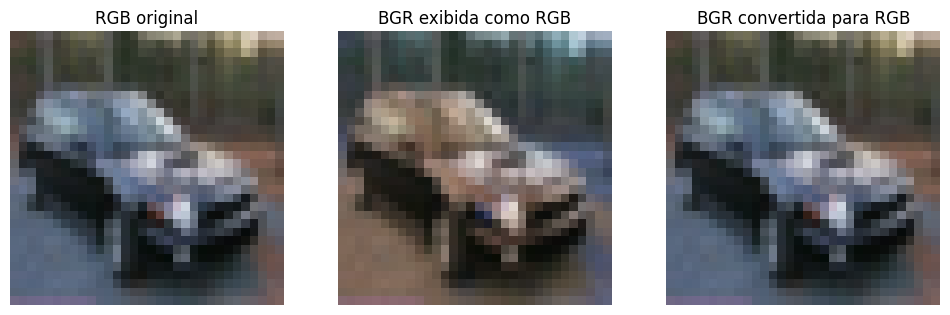

In [18]:
imagem_bgr = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2BGR)

# Complete a conversão correta:
imagem_corrigida = cv2.cvtColor(imagem_bgr, cv2.COLOR_RGB2BGR)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(imagem_rgb)
plt.title("RGB original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(imagem_bgr)
plt.title("BGR exibida como RGB")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(imagem_corrigida)
plt.title("BGR convertida para RGB")
plt.axis("off")

plt.show()

# 5. Separação dos canais RGB

Complete:

Canal R: posição 0 da matriz.

Canal G: posição 1 da matriz.

Canal B: posição 2 da matriz.

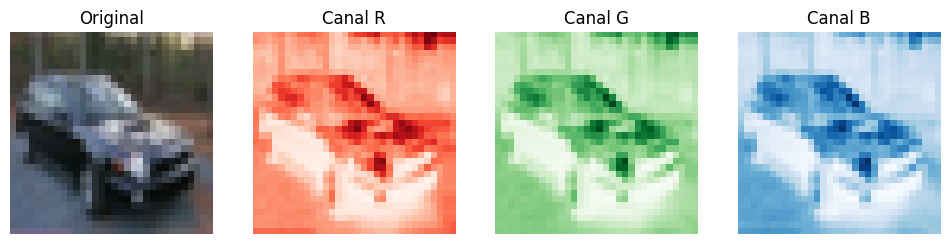

In [19]:
canal_r = imagem_rgb[:, :, 0]
canal_g = imagem_rgb[:, :, 1]
canal_b = imagem_rgb[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(imagem_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(canal_r, cmap="Reds")
plt.title("Canal R")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(canal_g, cmap="Greens")
plt.title("Canal G")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(canal_b, cmap="Blues")
plt.title("Canal B")
plt.axis("off")

plt.show()

# 6. Conversão para tons de cinza

Complete:

A imagem RGB possui 3 canais.

A imagem em tons de cinza possui apenas 1 matriz de intensidade.

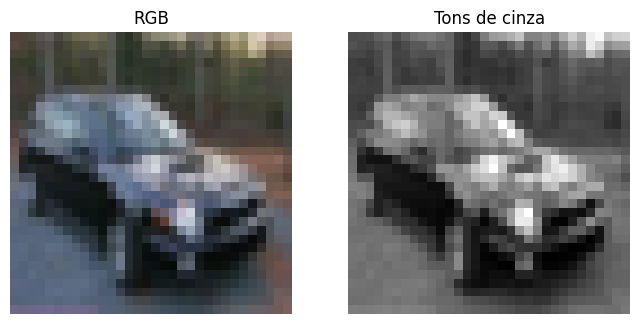

Formato RGB: (32, 32, 3)
Formato cinza: (32, 32)


In [20]:
imagem_gray = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagem_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagem_gray, cmap="gray")
plt.title("Tons de cinza")
plt.axis("off")

plt.show()

print("Formato RGB:", imagem_rgb.shape)
print("Formato cinza:", imagem_gray.shape)

# 7. Redimensionamento

Complete:

Redimensionar significa alterar a largura e a altura da imagem.

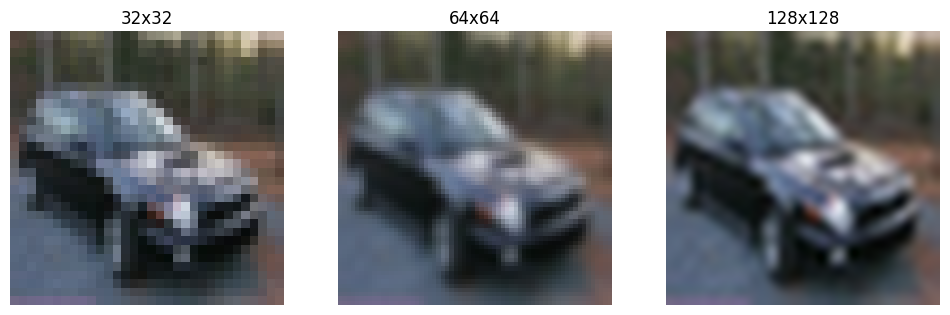

In [21]:
imagem_64 = cv2.resize(imagem_rgb, (64, 64), interpolation=cv2.INTER_LINEAR)
imagem_128 = cv2.resize(imagem_rgb, (1200, 1200), interpolation=cv2.INTER_LANCZOS4)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(imagem_rgb)
plt.title("32x32")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(imagem_64)
plt.title("64x64")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(imagem_128)
plt.title("128x128")
plt.axis("off")

plt.show()

# 8. Histograma

Complete:

O histograma mostra a distribuição dos valores de  intensidade dos pixels (ou níveis de cinza / cores).

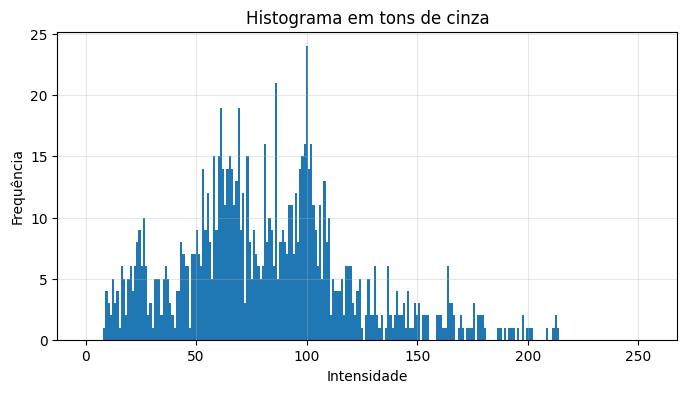

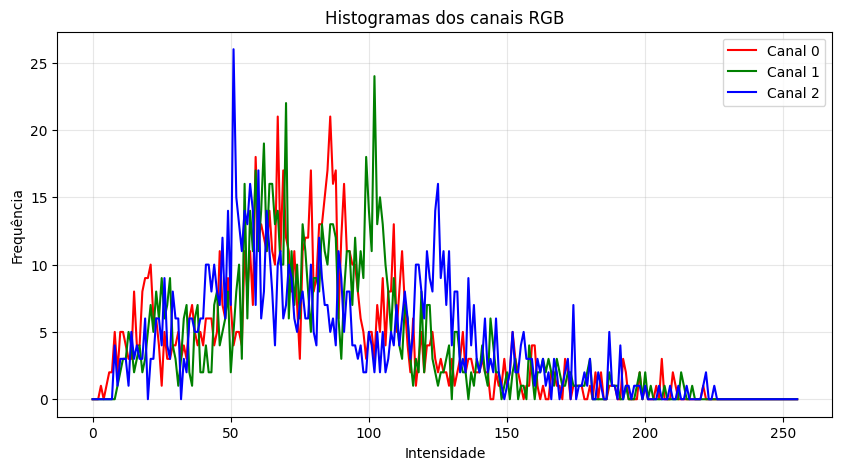

In [22]:
plt.figure(figsize=(8,4))
plt.hist(imagem_gray.ravel(), bins=256, range=(0,255))
plt.title("Histograma em tons de cinza")
plt.xlabel("Intensidade")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,5))
for i, cor in enumerate(["red", "green", "blue"]):
    hist = cv2.calcHist([imagem_rgb], [i], None, [256], [0,256])
    plt.plot(hist, color=cor, label=f"Canal {i}")

plt.title("Histogramas dos canais RGB")
plt.xlabel("Intensidade")
plt.ylabel("Frequência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 9. Filtro Gaussian Blur

Complete:

O Gaussian Blur é usado para suavizar a imagem e reduzir ruidos.

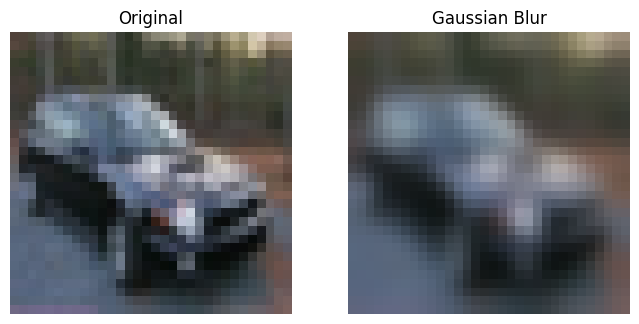

In [23]:
imagem_blur = cv2.GaussianBlur(imagem_rgb, (5, 5), 0)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagem_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagem_blur)
plt.title("Gaussian Blur")
plt.axis("off")

plt.show()

# 10. Detecção de bordas com Canny

Complete:

A detecção de bordas identifica mudanças bruscas de intensidade dos pixels (ou níveis de brilho/cor).

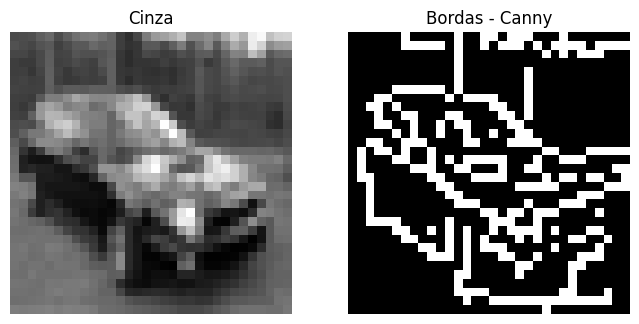

In [24]:
bordas = cv2.Canny(imagem_gray, threshold1=50, threshold2=150)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagem_gray, cmap="gray")
plt.title("Cinza")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(bordas, cmap="gray")
plt.title("Bordas - Canny")
plt.axis("off")

plt.show()

# 11. Limiarização

Complete:

A limiarização transforma uma imagem em tons de cinza em uma imagem binária (preto e branco).

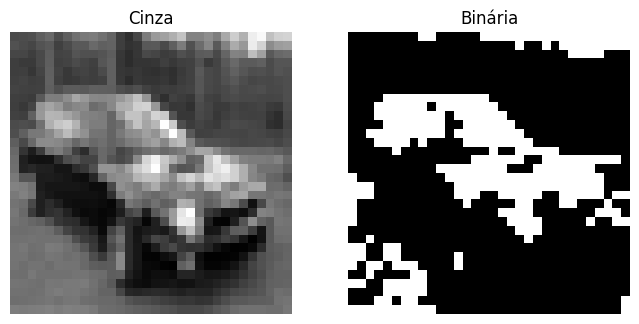

In [25]:
limiar = 100
_, imagem_binaria = cv2.threshold(imagem_gray, limiar, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(imagem_gray, cmap="gray")
plt.title("Cinza")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagem_binaria, cmap="gray")
plt.title("Binária")
plt.axis("off")

plt.show()

# 12. Visualização geral do dataset

Execute a célula e observe as classes.

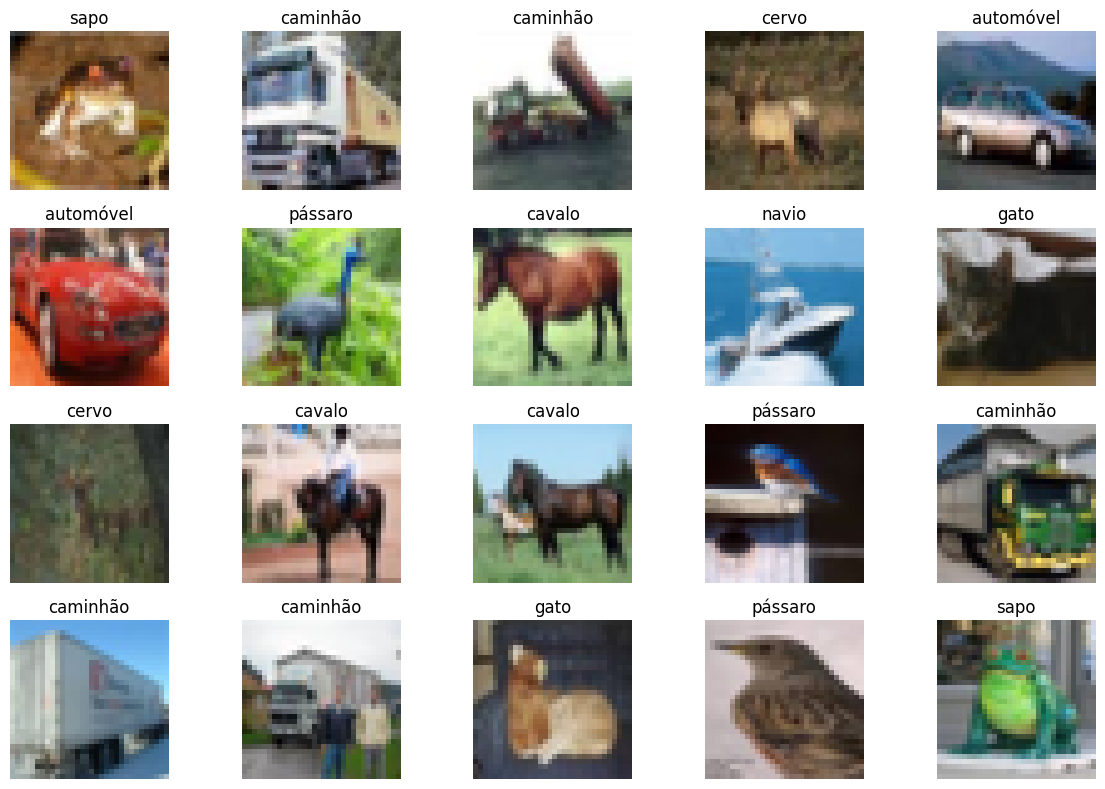

In [26]:
plt.figure(figsize=(12,8))

for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x_train[i])
    plt.title(classes[int(y_train[i][0])])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 13. Distribuição das classes

Execute e responda:

O dataset está balanceado? Justifique.
Sim, as distribuições de classes estão iguais.

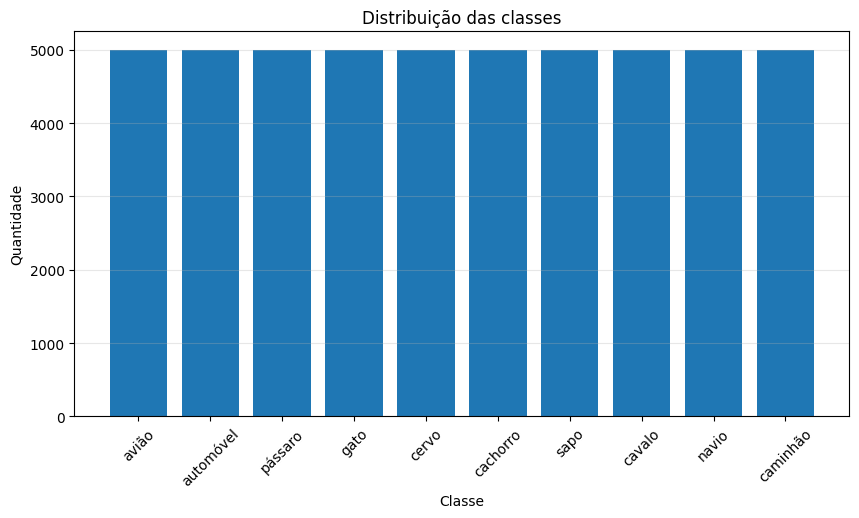

In [28]:
valores, contagens = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))
plt.bar([classes[int(v)] for v in valores], contagens)
plt.xticks(rotation=45)
plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 14. Normalização e treinamento simples

Complete os campos em branco.

In [29]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

x_train_small = x_train_norm[:5000]
y_train_small = y_train[:5000]
x_test_small = x_test_norm[:1000]
y_test_small = y_test[:100]

modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

modelo.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=["accuracy"]
)

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
historico = modelo.fit(
    x_train_small,
    y_train_small,
    epochs=500,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

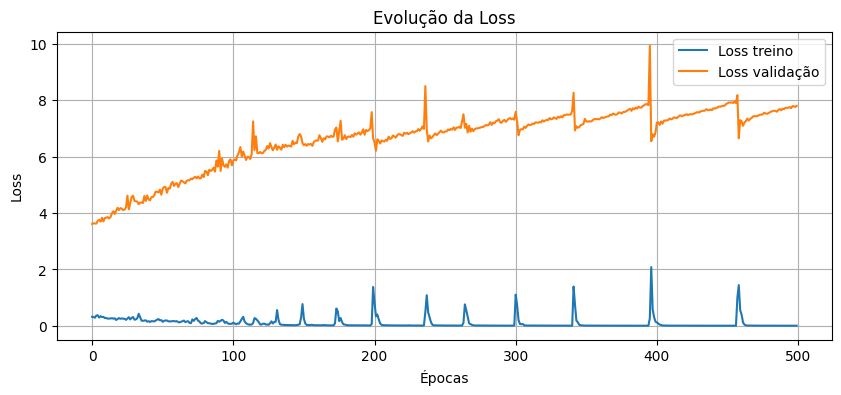

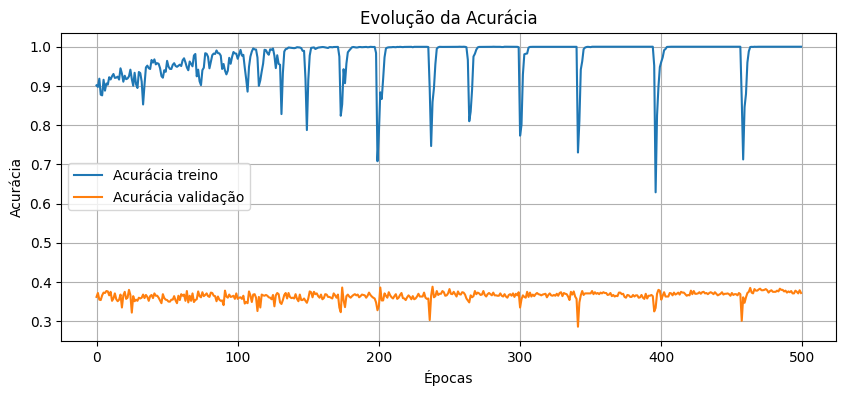

In [32]:
plt.figure(figsize=(10,4))
plt.plot(historico.history["loss"], label="Loss treino")
plt.plot(historico.history["val_loss"], label="Loss validação")
plt.title("Evolução da Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(historico.history["accuracy"], label="Acurácia treino")
plt.plot(historico.history["val_accuracy"], label="Acurácia validação")
plt.title("Evolução da Acurácia")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.show()

# 15. Atividade avaliativa

Responda no final do notebook:

1. O que é um pixel?
É a menor unidade de uma imagem digital, representando um ponto com um valor de cor ou intensidade.

2. O que são canais RGB?
São os três canais de cor: vermelho (R), verde (G) e azul (B) que, combinados, formam uma imagem colorida.

3. Qual é a diferença entre RGB e BGR?
A diferença está na ordem dos canais:
RGB → Vermelho, Verde, Azul
BGR → Azul, Verde, Vermelho

4. Por que é importante converter corretamente imagens usadas com OpenCV?
Porque o OpenCV usa o padrão BGR. Se não houver conversão correta, as cores ficam trocadas.

5. Para que serve converter uma imagem para tons de cinza?
Para reduzir a complexidade da imagem, facilitando o processamento e análise.

6. Para que serve redimensionar imagens?
Para alterar largura e altura, padronizar ou otimizar o processamento.

7. O que um histograma permite analisar?
Permite analisar a distribuição dos valores de intensidade dos pixels.

8. Para que serve o Gaussian Blur?
Serve para suavizar a imagem e reduzir ruídos.

9. Para que serve a detecção de bordas?
Serve para identificar contornos e mudanças bruscas de intensidade.

10. O que é limiarização?
É o processo de transformar uma imagem em tons de cinza em uma imagem binária (preto e branco).

11. Cite uma aplicação industrial possível para OpenCV e visão computacional.
Exemplo: inspeção de qualidade, detectando defeitos em peças automaticamente.
